## Introduction to Pandas For Time Series Analysis

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
ticker = input("Enter stock ticker (e.g. AAPL): ").upper()
ticker_2=input("Enter stock ticker(e.g. AMZN)").upper()
start_date = input("Enter start date for data (YYYY-MM-DD): ")
end_date = input("Enter end date for data (YYYY-MM-DD): ")


Enter stock ticker (e.g. AAPL): AAPL
Enter stock ticker(e.g. AMZN)AMZN
Enter start date for data (YYYY-MM-DD): 2018-01-01
Enter end date for data (YYYY-MM-DD): 2025-04-17


##### Importing Time Series Data and Manipulation

###### Building checks in your data workflow

In [ ]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# 📈

# Download data safely
stock_1 = yf.download(ticker, start=start_date, end=end_date)
stock_2 = yf.download(ticker_2, start=start_date, end=end_date)

# Check if data was returned properly
if stock_1.empty:
    raise ValueError(f"No stock data returned for {ticker}. Check ticker symbol and date range.")

if stock_2.empty:
    raise ValueError(f"No market data returned for {ticker_2}. Check date range.")

# Use Close price
stock_1 = stock_1['Close'].reset_index()
stock_2 = stock_2['Close'].reset_index()

stock_1=stock_1[['Date',ticker]]
stock_2=stock_2[['Date',ticker_2]]
df=pd.merge(stock_1,stock_2,on='Date')


df['stock_1_ret'] = df[ticker].pct_change()
df['stock_2_ret'] = df[ticker_2].pct_change()
df.dropna(inplace=True)
df.info()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
Index: 1832 entries, 1 to 1832
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1832 non-null   datetime64[ns]
 1   AAPL         1832 non-null   float64       
 2   AMZN         1832 non-null   float64       
 3   stock_1_ret  1832 non-null   float64       
 4   stock_2_ret  1832 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 85.9 KB


###### Explanation of datetime64

What does `[ns]` mean in `datetime64[ns]`?

The `[ns]` in `datetime64[ns]` stands for **nanoseconds**, and it refers to the **precision** or **resolution** of the datetime values in pandas or NumPy.

Explanation:

- `datetime64` is the data type used to represent dates and times.
- `[ns]` indicates that the timestamps are stored with **nanosecond precision**, i.e., 1 billionth of a second.

Available Time Unit Resolutions:

| Time Unit | Meaning       | Example                         |
|-----------|----------------|----------------------------------|
| `Y`       | Year          | `2022`                           |
| `M`       | Month         | `2022-01`                        |
| `D`       | Day           | `2022-01-01`                     |
| `h`       | Hour          | `2022-01-01T01`                  |
| `m`       | Minute        | `2022-01-01T01:30`               |
| `s`       | Second        | `2022-01-01T01:30:00`            |
| `ms`      | Millisecond   | `2022-01-01T01:30:00.123`        |
| `us`      | Microsecond   | `2022-01-01T01:30:00.123456`     |
| `ns`      | Nanosecond    | `2022-01-01T01:30:00.123456789`  |

Why does pandas use `[ns]`?

- It provides **maximum precision** by default.
- It's standardized for internal consistency.
- Even if you don’t need nanosecond timestamps, it allows precise operations like high-frequency financial data.

Even if your data only has dates (not times), pandas still stores them as `datetime64[ns]` so that time-based operations and indexing work consistently.


###### Difference



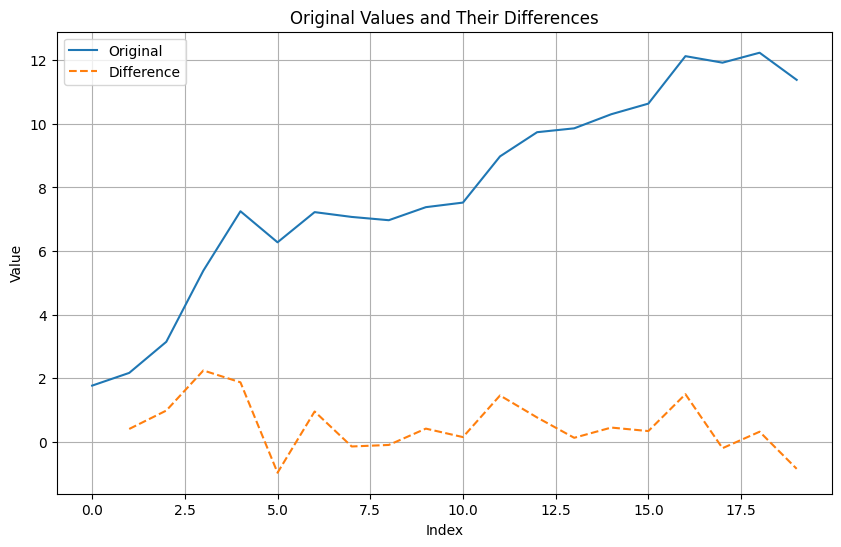

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create a sample DataFrame
np.random.seed(0)
data = np.random.randn(20).cumsum()  # Simulate a cumulative sum series
df = pd.DataFrame({'original': data})

# Step 2: Take the difference
df['difference'] = df['original'].diff()

# Step 3: Plot original vs. difference
plt.figure(figsize=(10, 6))
plt.plot(df['original'], label='Original')
plt.plot(df['difference'], label='Difference', linestyle='--')
plt.title('Original Values and Their Differences')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


###### Percentage Change

```pct_change```

In [ ]:
stock_1=stock_1[['Date',ticker]]
stock_2=stock_2[['Date',ticker_2]]
df=pd.merge(stock_1,stock_2,on='Date')


df['stock_1_ret'] = df[ticker].pct_change()
df['stock_2_ret'] = df[ticker_2].pct_change()
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1832 entries, 1 to 1832
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1832 non-null   datetime64[ns]
 1   AAPL         1832 non-null   float64       
 2   AMZN         1832 non-null   float64       
 3   stock_1_ret  1832 non-null   float64       
 4   stock_2_ret  1832 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 85.9 KB


In [ ]:
df

Ticker,Date,AAPL,AMZN,stock_1_ret,stock_2_ret
1,2020-01-03,72.009109,93.748497,-0.009722,-0.012139
2,2020-01-06,72.582916,95.143997,0.007969,0.014886
3,2020-01-07,72.241554,95.343002,-0.004703,0.002092
4,2020-01-08,73.403648,94.598503,0.016086,-0.007809
5,2020-01-09,74.962814,95.052498,0.021241,0.004799
...,...,...,...,...,...
1324,2025-04-09,198.850006,191.100006,0.153289,0.119770
1325,2025-04-10,190.419998,181.220001,-0.042394,-0.051701
1326,2025-04-11,198.149994,184.869995,0.040594,0.020141
1327,2025-04-14,202.520004,182.119995,0.022054,-0.014875


###### Shift Operator

Forward Shift

In [ ]:
df.head(10)

Ticker,Date,AAPL,AMZN,stock_1_ret,stock_2_ret
1,2020-01-03,72.009109,93.748497,-0.009722,-0.012139
2,2020-01-06,72.582916,95.143997,0.007969,0.014886
3,2020-01-07,72.241554,95.343002,-0.004703,0.002092
4,2020-01-08,73.403648,94.598503,0.016086,-0.007809
5,2020-01-09,74.962814,95.052498,0.021241,0.004799
6,2020-01-10,75.132248,94.157997,0.002260,-0.009411
7,2020-01-13,76.737427,94.565002,0.021365,0.004323
8,2020-01-14,75.701218,93.472000,-0.013503,-0.011558
9,2020-01-15,75.376778,93.100998,-0.004286,-0.003969
10,2020-01-16,76.321022,93.897003,0.012527,0.008550


In [ ]:
df['AAPL_shift_1']=df['AAPL'].shift(1)
df=df[['Date','AAPL','AAPL_shift_1']]
df.head(5)

Ticker,Date,AAPL,AAPL_shift_1
1,2020-01-03,72.009109,NaN
2,2020-01-06,72.582916,72.009109
3,2020-01-07,72.241554,72.582916
4,2020-01-08,73.403648,72.241554
5,2020-01-09,74.962814,73.403648


Backward Shift

In [ ]:
df['AAPL_shift_1']=df['AAPL'].shift(-1)
df=df[['Date','AAPL','AAPL_shift_1']]
df.head(5)

Ticker,Date,AAPL,AAPL_shift_1
1,2018-01-03,40.472790,40.660778
2,2018-01-04,40.660778,41.123718
3,2018-01-05,41.123718,40.970978
4,2018-01-08,40.970978,40.966274
5,2018-01-09,40.966274,40.956867


##### Slicing Data

###### Slicing by Date




In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download AAPL data from 2022 to 2023
df = yf.download('AAPL', start='2022-01-01', end='2024-01-01')  # End is exclusive
by_day=df['2022-01-01':'2023-01-01']
by_month=df['2022-01':'2022-12']
by_year=df['2022':'2022']
by_month

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.879913,179.734962,174.653874,174.771805,104487900
2022-01-04,176.609634,179.793920,176.039607,179.489254,99310400
2022-01-05,171.911835,177.071549,171.636651,176.521181,94537600
2022-01-06,169.042068,172.285320,168.688259,169.730027,96904000
2022-01-07,169.209122,171.145244,168.088727,169.916741,86709100
...,...,...,...,...,...
2022-12-23,130.344482,130.898044,128.149997,129.415284,63814900
2022-12-27,128.535522,129.899667,127.240581,129.870013,69007800


##### Visualizing Simple Time Series

###### Plotting one series

Text(0, 0.5, 'AAPL')

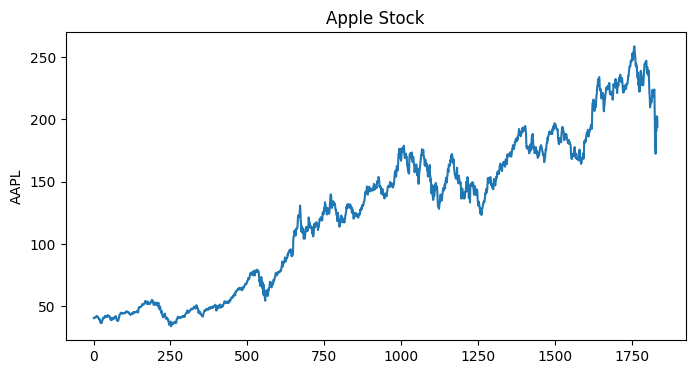

In [ ]:
df['AAPL'].plot(figsize=(8,4),title='Apple Stock')
plt.ylabel('AAPL')

###### Plotting two series

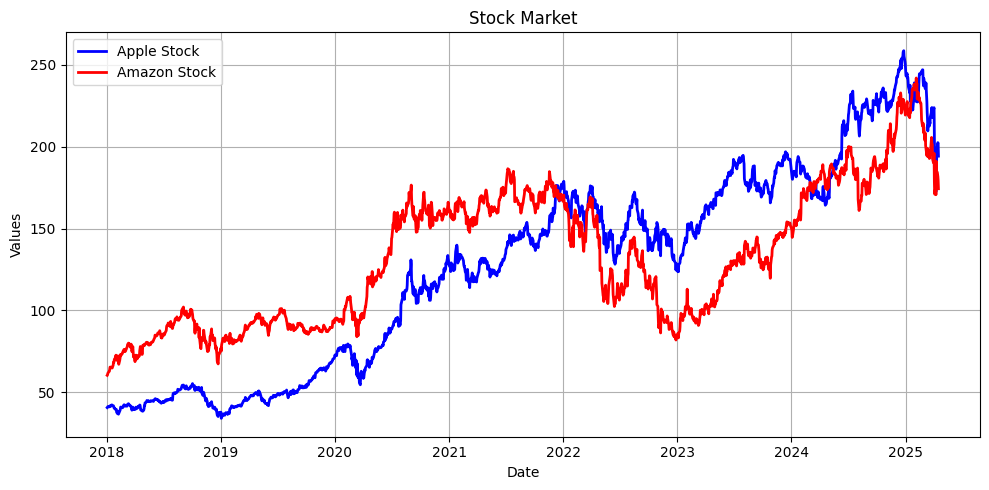

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df.Date, df['AAPL'], label='Apple Stock', color='blue', linewidth=2)
plt.plot(df.Date, df['AMZN'], label='Amazon Stock', color='red', linewidth=2)
#plt.yscale('log')  # 👈 LOG SCALE here

plt.title('Stock Market')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


###### Rolling averages and plots


[*********************100%***********************]  1 of 1 completed


<Figure size 1400x600 with 0 Axes>

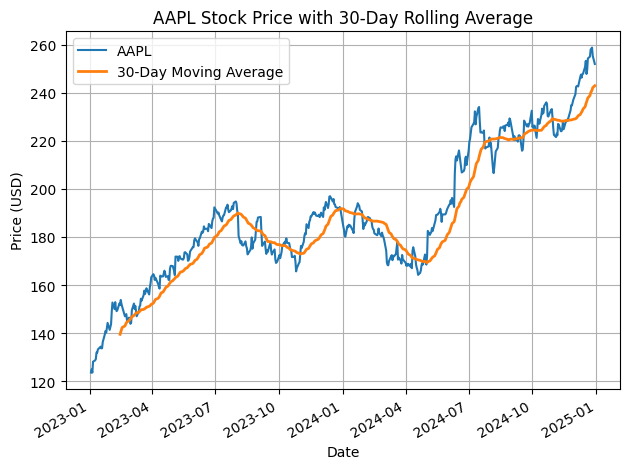

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download AAPL data from Yahoo Finance
df = yf.download('AAPL', start='2023-01-01', end='2024-12-31')

# Calculate 30-day rolling average of the closing price
df['30D_MA'] = df['Close'].rolling(window=30).mean()

# Plot the closing price and the 30-day moving average
plt.figure(figsize=(14, 6))
df['Close'].plot(label='AAPL Close Price')
df['30D_MA'].plot(label='30-Day Moving Average', linewidth=2)

plt.title('AAPL Stock Price with 30-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



###### Visualizing Using Markers

One key moment was in May 2019, when the U.S. increased tariffs on $200 billion worth of Chinese goods from 10% to 25% (announced May 5, 2019; implemented May 10, 2019). This was a major escalation in the U.S.–China trade war and affected market sentiment significantly.

```ax.axvspan``` is used to create markers

[*********************100%***********************]  1 of 1 completed


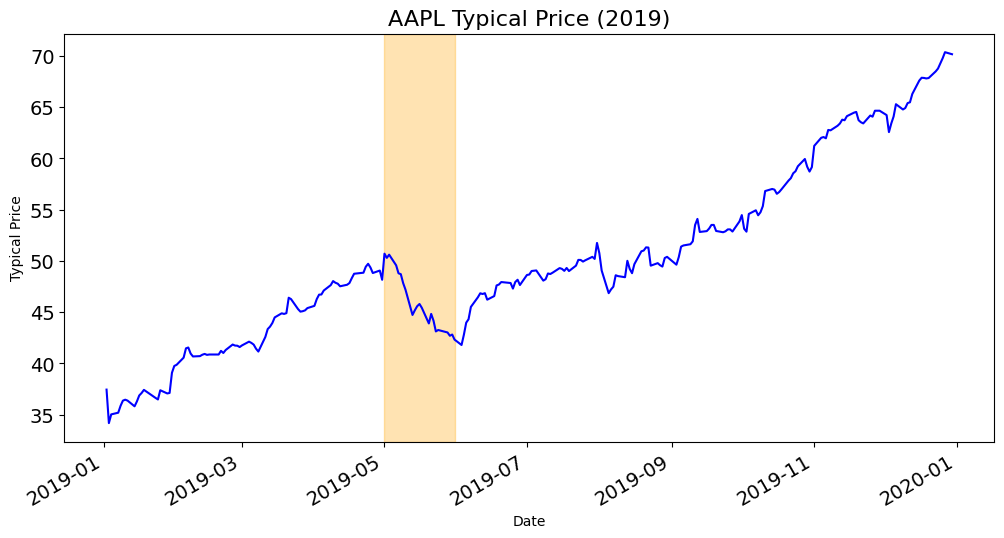

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Download AAPL data for 2019
df = yf.download('AAPL', start='2019-01-01', end='2019-12-31')

# Step 2: Calculate Typical Price (High + Low + Close) / 3
df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3

# Step 3: Subset for plotting (Typical Price)
price_subset = df['Typical_Price']

# Step 4: Plotting the Typical Price
ax = price_subset.plot(color='blue', fontsize=14, figsize=(12,6))
ax.set_title('AAPL Typical Price (2019)', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Typical Price')

# Step 5: Highlight May 2019 (Tariff Announcement)
ax.axvspan('2019-05-01', '2019-05-31', color='orange', alpha=0.3)

# Display the plot
plt.show()



###### Examining a Specific Period

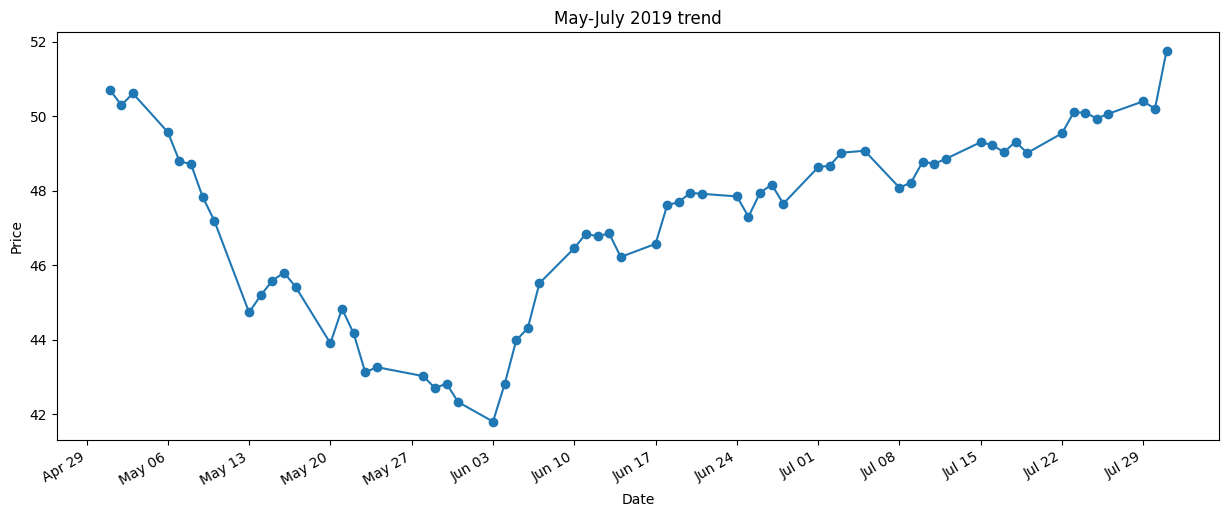

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

ax = df.loc['2019-05':'2019-07','Typical_Price'].plot(marker='o', linestyle='-',figsize=(15,6))
ax.set_title('May-July 2019 trend');
ax.set_ylabel('Price');
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

`mdates.MONDAY` in `matplotlib.dates`

In the context of `mdates.MONDAY` used with `mdates.WeekdayLocator(byweekday=mdates.MONDAY)`:

- **`mdates.MONDAY`** is a constant in the `matplotlib.dates` module that represents **Monday** as the day of the week.
- It’s used to specify the **weekday** on which the major ticks of the x-axis should appear when using a **`WeekdayLocator`**.

Example Usage:

```python
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))


###### Kernal Density Plot

<ipython-input-110-b845851877f9>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Typical_Price'],shade=True)


<Axes: xlabel='Typical_Price', ylabel='Density'>

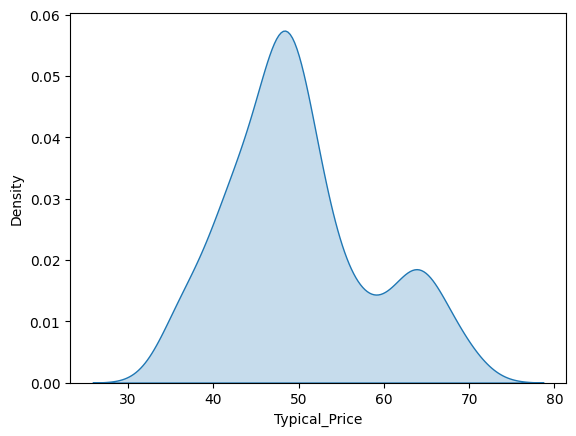

In [ ]:
import seaborn as sns

sns.kdeplot(df['Typical_Price'],shade=True)


##### Date Range

| Parameter      | Description                                                                 | Example                                                  |
|----------------|-----------------------------------------------------------------------------|----------------------------------------------------------|
| `start`        | Starting date of the range                                                  | `'2023-01-01'`, `pd.Timestamp('2023-01-01')`             |
| `end`          | Ending date of the range                                                    | `'2023-12-31'`                                           |
| `periods`      | Number of time points to generate                                           | `periods=12` (use instead of `end`)                      |
| `freq`         | Frequency string (see list below)                                           | `'D'`, `'B'`, `'M'`, `'H'`, etc.                         |
| `tz`           | Time zone string                                                            | `'UTC'`, `'America/New_York'`                           |
| `normalize`    | Set time to midnight (00:00:00) on each timestamp                          | `normalize=True`                                        |
| `name`         | Name of the resulting index                                                 | `'my_dates'`                                             |
| `inclusive`    | Whether to include both endpoints (default `'both'`)                        | `'both'`, `'left'`, `'right'`, `'neither'`              |
| `closed` ⚠️    | (Deprecated) Which endpoint to include — use `inclusive` instead            | `'left'`, `'right'`                                     |

---

| Code     | Frequency         | Description                                |
|----------|-------------------|--------------------------------------------|
| `'D'`    | Daily              | Calendar day                               |
| `'B'`    | Business day       | Weekdays (Mon–Fri), no holidays            |
| `'W'`    | Weekly             | Weekly (defaults to Sunday end)            |
| `'M'`    | Month end          | Last calendar day of the month             |
| `'MS'`   | Month start        | First calendar day of the month            |
| `'Q'`    | Quarter end        | Mar, Jun, Sep, Dec                         |
| `'QS'`   | Quarter start      | Jan, Apr, Jul, Oct                         |
| `'A'`    | Year end           | December 31                                |
| `'AS'`   | Year start         | January 1                                  |
| `'H'`    | Hourly             | Every hour                                 |
| `'T'` / `'min'` | Minutely   | Every minute                               |
| `'S'`    | Secondly           | Every second                               |
| `'L'`    | Millisecond        | Every millisecond                          |
| `'U'`    | Microsecond        | Every microsecond                          |


```pd.date_range```

###### Example 1: Daily Data

In [ ]:
dates=pd.date_range(start='2020-01-01',end='2021-12-31')
dates

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10',
               ...
               '2021-12-22', '2021-12-23', '2021-12-24', '2021-12-25',
               '2021-12-26', '2021-12-27', '2021-12-28', '2021-12-29',
               '2021-12-30', '2021-12-31'],
              dtype='datetime64[ns]', length=731, freq='D')

###### Example 2: Hourly Data

In [ ]:
dates=pd.date_range(start='2020-01-01',end='2021-01-02',freq='h')
dates

DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 01:00:00',
               '2020-01-01 02:00:00', '2020-01-01 03:00:00',
               '2020-01-01 04:00:00', '2020-01-01 05:00:00',
               '2020-01-01 06:00:00', '2020-01-01 07:00:00',
               '2020-01-01 08:00:00', '2020-01-01 09:00:00',
               ...
               '2021-01-01 15:00:00', '2021-01-01 16:00:00',
               '2021-01-01 17:00:00', '2021-01-01 18:00:00',
               '2021-01-01 19:00:00', '2021-01-01 20:00:00',
               '2021-01-01 21:00:00', '2021-01-01 22:00:00',
               '2021-01-01 23:00:00', '2021-01-02 00:00:00'],
              dtype='datetime64[ns]', length=8809, freq='h')

###### Example 3:Business Days

In [ ]:
dates=pd.date_range(start='2020-01-01',end='2021-12-31',freq='B')
dates

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-06',
               '2020-01-07', '2020-01-08', '2020-01-09', '2020-01-10',
               '2020-01-13', '2020-01-14',
               ...
               '2021-12-20', '2021-12-21', '2021-12-22', '2021-12-23',
               '2021-12-24', '2021-12-27', '2021-12-28', '2021-12-29',
               '2021-12-30', '2021-12-31'],
              dtype='datetime64[ns]', length=523, freq='B')

###### Example 4: Excluding Holidays

As a check, we can see that 01-20-2020 which is MLK day, was excluded.

In [ ]:
from pandas.tseries.offsets import CustomBusinessDay
from pandas.tseries.holiday import USFederalHolidayCalendar

custom_bday = CustomBusinessDay(calendar=USFederalHolidayCalendar())
pd.date_range(start='2020-01-01',end='2020-01-31', freq=custom_bday)


DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15', '2020-01-16', '2020-01-17',
               '2020-01-21', '2020-01-22', '2020-01-23', '2020-01-24',
               '2020-01-27', '2020-01-28', '2020-01-29', '2020-01-30',
               '2020-01-31'],
              dtype='datetime64[ns]', freq='C')

#### Time Delta

##### Creating a window of 10 days before and 10 days after a date.

In [ ]:
import pandas as pd

# Create a date
date = pd.to_datetime('2023-04-16')

# Define a timedelta (e.g., 10 days)
delta = pd.Timedelta(days=10)

# Add 10 days to the date
new_date = date + delta

# Subtract 10 days from the date
previous_date = date - delta

print("Original date:", date)
print("New date (+10 days):", new_date)
print("Previous date (-10 days):", previous_date)


Original date: 2023-04-16 00:00:00
New date (+10 days): 2023-04-26 00:00:00
Previous date (-10 days): 2023-04-06 00:00:00


#### Time Stamp

##### Taking a simple time stamp

pd.Timestamp is a core component of Pandas that represents a **single point in time.**

In [ ]:
import pandas as pd

# Create a Timestamp from a string
ts = pd.Timestamp('2023-04-16')

print(ts)


2023-04-16 00:00:00


##### Using it with Time Delta

In [ ]:
ts_new = ts + pd.Timedelta(days=5)
print(ts_new)  # Adds 5 days to the timestamp


2023-04-21 00:00:00


AttributeError: 'Timestamp' object has no attribute 'dtype'

#### Using Date Range, Time Stamp and Time Delta Together

In [ ]:
import pandas as pd
import numpy as np

# Generate stock price data for 2022
dates = pd.date_range(start='2022-01-01', end='2022-12-31', freq='B')  # Only business days
stock_prices = 100 + np.cumsum(np.random.randn(len(dates)))

# Create a DataFrame
df = pd.DataFrame({'price': stock_prices}, index=dates)

# Manually define earnings dates using pd.Timestamp
earnings_dates = [
    pd.Timestamp('2022-02-15')
]

# Add a column to flag the earnings events
df['event_flag'] = 0  # Initialize with zeros

# Flag the event days around each earnings date
for date in earnings_dates:
    # Create a window of 7 days before and after the earnings date
    window = pd.date_range(start=date - pd.Timedelta(days=7),
                           end=date + pd.Timedelta(days=7), freq='B')

    # Set the flag to 1 for all dates within the window
    df.loc[window, 'event_flag'] = 1

# Now you have the data with a flag indicating event windows
df.head(20)  # Inspect the first 20 rows


,price,event_flag
2022-01-03,100.229954,0
2022-01-04,99.321652,0
2022-01-05,99.083119,0
2022-01-06,98.304105,0
2022-01-07,96.138460,0
2022-01-10,97.112722,0
2022-01-11,96.601271,0
2022-01-12,95.840871,0
2022-01-13,96.051441,0
2022-01-14,96.563941,0


In [ ]:
# Filter the data for event days (flag = 1)
event_data = df[df['event_flag'] == 1]

event_data



,price,event_flag
2022-02-08,95.496432,1
2022-02-09,94.814102,1
2022-02-10,93.618004,1
2022-02-11,93.578266,1
2022-02-14,92.604516,1
2022-02-15,90.831906,1
2022-02-16,91.635352,1
2022-02-17,92.487518,1
2022-02-18,91.628680,1
2022-02-21,91.872644,1


#### Transforming an Object or string To Date

In [ ]:
import pandas as pd

# Sample DataFrame with 'object' dtype
df = pd.DataFrame({
    'date_str': ['2022-01-01', '2022-03-15', '2022-08-15']
})

print(df.dtypes)


date_str    object
dtype: object


In [ ]:
df['date'] = pd.to_datetime(df['date_str'])
print(df.dtypes)


date_str            object
date        datetime64[ns]
dtype: object


##### Formatting

| Code | Meaning              | Example       |
|------|----------------------|---------------|
| %d   | Day (zero-padded)    | 01 to 31      |
| %b   | Month (abbrev)       | Jan, Feb, ... |
| %B   | Month (full name)    | January       |
| %m   | Month (number)       | 01 to 12      |
| %Y   | Year (4-digit)       | 2025          |
| %y   | Year (2-digit)       | 25            |
| %H   | Hour (24-hour)       | 00 to 23      |
| %I   | Hour (12-hour)       | 01 to 12      |
| %p   | AM/PM                | AM, PM        |
| %M   | Minute               | 00 to 59      |
| %S   | Second               | 00 to 59      |
| %f   | Microsecond          | 000000


In [ ]:
df = pd.DataFrame({"date_str": ["04-16-2025", "05-01-2025"]})
df["date"] = pd.to_datetime(df["date_str"], format="%m-%d-%Y")
df

,date_str,date
0,04-16-2025,2025-04-16
1,05-01-2025,2025-05-01


In [ ]:
import pandas as pd

date_str = "16-Apr-2025"
dt = pd.to_datetime(date_str, format="%d-%b-%Y")
print(dt)


2025-04-16 00:00:00


#### Handling Missing Data

In [ ]:
import pandas as pd
import numpy as np

# Create a sample DataFrame with missing values
df = pd.DataFrame({
    'A': [1, np.nan, np.nan, 4, np.nan, 6],
    'B': [np.nan, 2, np.nan, 4, 5, np.nan]
})

print("Original DataFrame:")
print(df)


Original DataFrame:
     A    B
0  1.0  NaN
1  NaN  2.0
2  NaN  NaN
3  4.0  4.0
4  NaN  5.0
5  6.0  NaN


##### Forward Fill

In [ ]:
df_ffill = df.ffill()
print("\nForward Fill:")
print(df_ffill)



Forward Fill:
     A    B
0  1.0  NaN
1  1.0  2.0
2  1.0  2.0
3  4.0  4.0
4  4.0  5.0
5  6.0  5.0


##### Backward Fill

In [ ]:
df_bfill = df.bfill()
print("\nBackward Fill:")
print(df_bfill)



Backward Fill:
     A    B
0  1.0  2.0
1  4.0  2.0
2  4.0  4.0
3  4.0  4.0
4  6.0  5.0
5  6.0  NaN


####Time Resampling

##### Year End

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Download AAPL data for 2019
df = yf.download('AAPL', start='2019-01-01', end='2024-12-31')

# Step 2: Calculate Typical Price (High + Low + Close) / 3
df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
df['Typical_Price'].resample(rule = 'YE').mean()[:5]

[*********************100%***********************]  1 of 1 completed


,Typical_Price
Date,
2019-12-31,50.086817
2020-12-31,92.798244
2021-12-31,138.142783
2022-12-31,152.584239
2023-12-31,171.008466


##### Monthly

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Download AAPL data for 2019
df = yf.download('AAPL', start='2019-01-01', end='2019-12-31')

# Step 2: Calculate Typical Price (High + Low + Close) / 3
df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
df['Typical_Price'].resample(rule = 'M').mean()[:5]

[*********************100%***********************]  1 of 1 completed
<ipython-input-130-2a6444427433>:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['Typical_Price'].resample(rule = 'M').mean()[:5]


,Typical_Price
Date,
2019-01-31,36.703901
2019-02-28,41.086776
2019-03-31,43.887321
2019-04-30,47.966559
2019-05-31,45.936357


##### Weekly

In [ ]:

# Step 2: Calculate Typical Price (High + Low + Close) / 3

df['Typical_Price'].resample(rule = 'W').mean()

,Typical_Price
Date,
2019-01-06,35.553361
2019-01-13,36.053988
2019-01-20,36.704828
2019-01-27,36.822426
2019-02-03,38.581037
2019-02-10,41.047104
2019-02-17,40.840111
2019-02-24,41.107286
2019-03-03,41.735525


##### All Options

| Code | Description              | Example Output Interval       |
|------|--------------------------|-------------------------------|
| `A` or `Y`   | Year-end frequency         | 2023-12-31, 2024-12-31             |
| `Q`          | Quarter-end frequency      | 2023-03-31, 2023-06-30             |
| `M`          | Month-end frequency        | 2023-01-31, 2023-02-28             |
| `W`          | Weekly frequency (Sunday)  | 2023-04-09, 2023-04-16             |
| `W-MON`      | Weekly on Monday           | 2023-04-10, 2023-04-17             |
| `D`          | Daily frequency            | 2023-04-10, 2023-04-11             |
| `B`          | Business day frequency     | 2023-04-10, 2023-04-11 (Mon–Fri)   |
| `H`          | Hourly frequency           | 2023-04-10 01:00, 2023-04-10 02:00 |
| `T` or `min` | Minutely frequency         | 2023-04-10 01:00, 2023-04-10 01:01 |
| `S`          | Secondly frequency         | 2023-04-10 01:00:00, 01:00:01      |
| `L` or `ms`  | Millisecond frequency      | 01:00:00.001, 01:00:00.002         |
| `U` or `us`  | Microsecond frequency      | 01:00:00.000001, 000002            |
| `N`          | Nanosecond frequency       | Very high frequency                |


#### AutoCorrelation

This comes from statsmodels, but autocorrelation is very important in time series analysis.

[*********************100%***********************]  1 of 1 completed


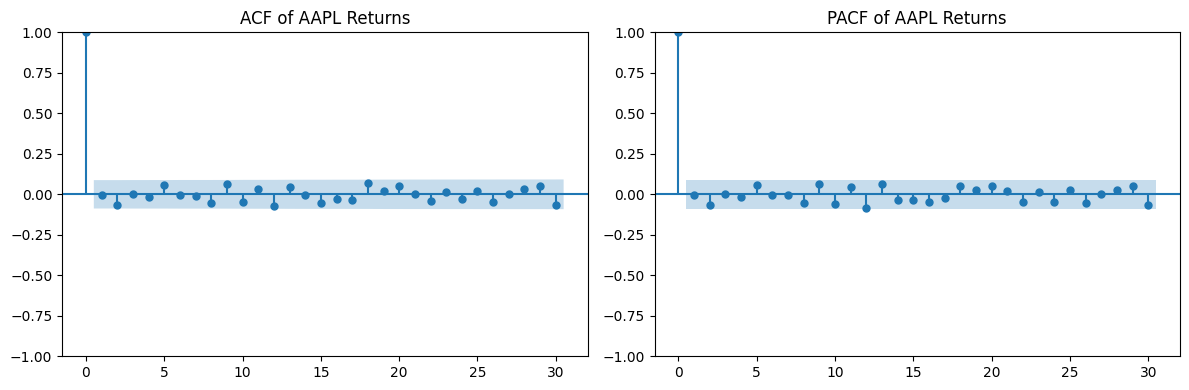

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

# Download Apple stock data
aapl = yf.download('AAPL', start='2022-01-01', end='2024-01-01')


# Daily returns
returns = aapl['Close'].pct_change().dropna()

# Plot ACF and PACF side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(returns, lags=30, ax=ax[0])
ax[0].set_title('ACF of AAPL Returns')

plot_pacf(returns, lags=30, ax=ax[1])
ax[1].set_title('PACF of AAPL Returns')

plt.tight_layout()
plt.show()




 ACF of AAPL Returns (Left Plot)
Lag 0 is always 1 (correlation with itself).

Lag 1 is slightly positive, and all other lags hover near zero within the blue confidence interval.

✅ This means:

Very little serial correlation.

Today’s return has almost no predictive power for future returns.

This supports the efficient market hypothesis (EMH) — price changes (returns) are essentially random.

✅ PACF of AAPL Returns (Right Plot)
Lag 1 shows a small spike, but like ACF, the rest are mostly inside the confidence band.

✅ This means:

No significant partial autocorrelations after lag 1.

There's no strong AR structure in the returns.

You might model this as white noise or possibly with a very low-order ARIMA model like ARIMA(0,0,0) or ARIMA(1,0,0) just to check.

#### Seasonal Decomposition

Seasonal Decomposition Formula

Seasonal decomposition of time series is typically done using one of two models: **additive** or **multiplicative**. The goal is to break down a time series into three components:

1. **Trend component (T)**: The underlying trend of the series.
2. **Seasonal component (S)**: The seasonal variations that repeat at regular intervals.
3. **Residual component (R)**: The noise or random fluctuations that remain after removing the trend and seasonal components.

The decomposition models can be expressed as:

**Additive Decomposition:**

$Y_t = T_t + S_t + R_t$

Where:
- $Y_t$ is the observed value at time $t$,
- $T_t$ is the trend component,
- $S_t$ is the seasonal component,
- $R_t$ is the residual or noise component.

**Multiplicative Decomposition:**

$Y_t = T_t \times S_t \times R_t$

Where:
- $Y_t$ is the observed value at time $t$,
- $T_t$ is the trend component,
- $S_t$ is the seasonal component,
- $R_t$ is the residual or noise component.

Selecting the Better Model

- **Additive decomposition** is useful when the seasonal variation remains roughly constant over time.
- **Multiplicative decomposition** is better when seasonal variations grow or shrink with the magnitude of the data.

Assessing the Best Model via Residuals

One way to determine which model fits better is by inspecting the **residuals** after decomposition. If the residuals (the part of the time series left after removing the trend and seasonal components) look approximately **normally distributed**, then that model is likely a better fit for the data. This is because a normal distribution in residuals suggests that the model has effectively captured the underlying patterns, leaving only random noise.

**In the context of AAPL stock prices:**
- If the residuals from the **multiplicative decomposition** look more normal (i.e., resemble a Gaussian distribution), then the **multiplicative model** is likely the better specification.
- Conversely, if the residuals from the **additive decomposition** look normal, then the **additive model** might be more appropriate.


[*********************100%***********************]  1 of 1 completed


<Figure size 1000x1000 with 0 Axes>

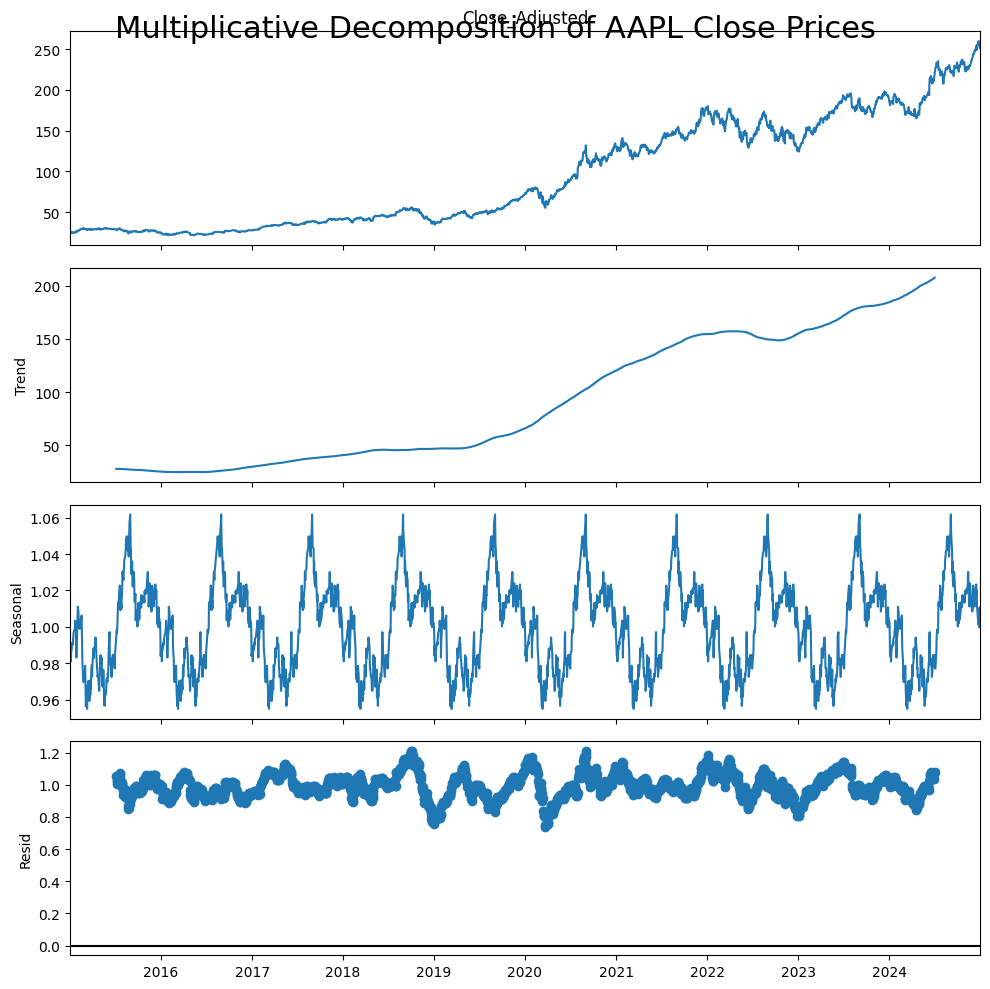

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Fetch AAPL stock data from Yahoo Finance using 'Close' prices
aapl = yf.download('AAPL', start='2015-01-01', end='2025-01-01')

# Add a small constant to Close prices for multiplicative decomposition (avoid zero values)
aapl['Close_Adjusted'] = aapl['Close'] + 1  # Avoid zero values by adding 1

# Seasonal decomposition (both additive and multiplicative) on 'Close' prices
result_additive = seasonal_decompose(aapl['Close'].dropna(), model='additive', period=252)
result_multiplicative = seasonal_decompose(aapl['Close_Adjusted'].dropna(), model='multiplicative', period=252)

# Plot the multiplicative decomposition
plt.figure()
result_multiplicative.plot()
plt.suptitle('Multiplicative Decomposition of AAPL Close Prices', fontsize=22)


# Display the plots
plt.show()


<Figure size 1000x1000 with 0 Axes>

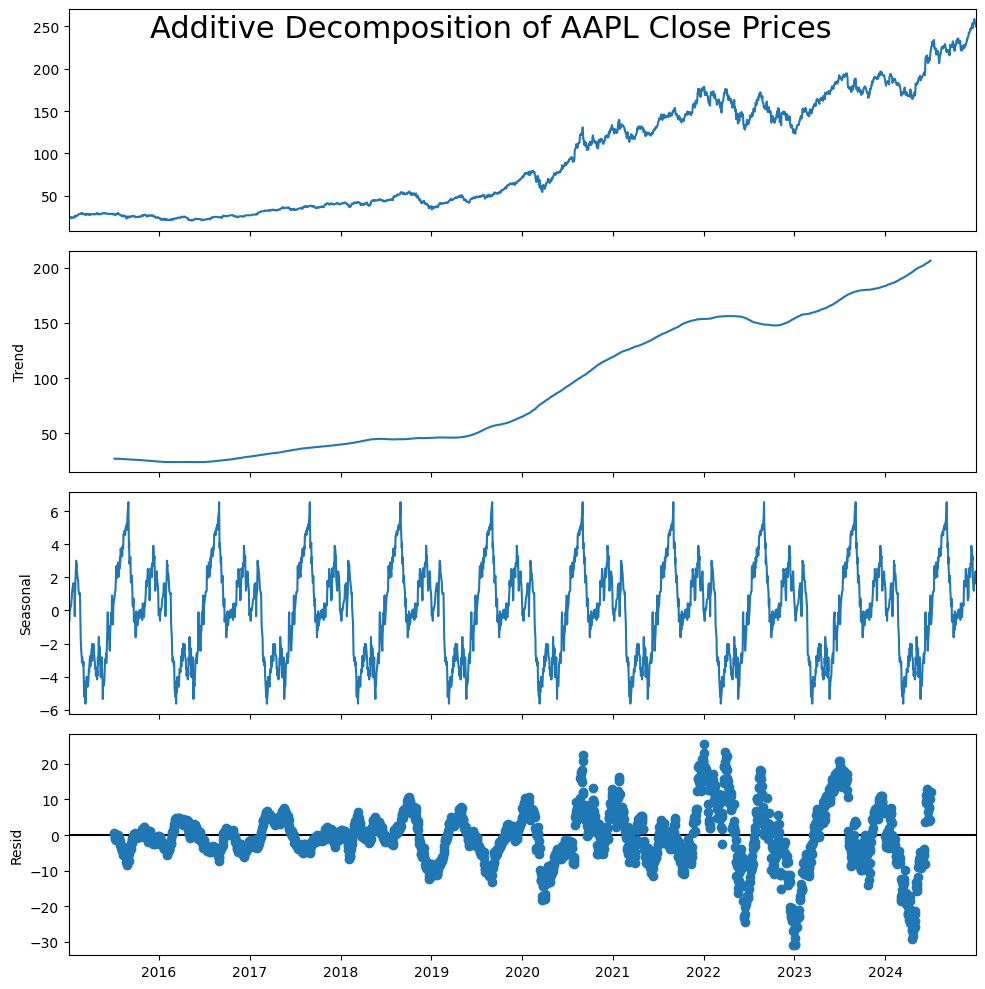

In [ ]:
# Plot the additive decomposition
plt.figure()
result_additive.plot()
plt.suptitle('Additive Decomposition of AAPL Close Prices', fontsize=22)
plt.show()

Difference:
Additive Decomposition: Assumes that the components (trend, seasonal, and residual) add together.

Multiplicative Decomposition: Assumes that the components multiply together, and this works well when seasonal effects grow or shrink in proportion to the level of the trend.

Does Apple lock into additive or multiplicative?
In general, multiplicative decomposition is often more suitable for stock prices like AAPL because of the inherent scaling of volatility and price fluctuations. As prices rise, the magnitude of fluctuations (including seasonal effects) can increase, making the multiplicative model a better fit for financial time series data.

##### Extract Components

In [ ]:
# Convert the decomposed components to pandas Series and fill NaN values
seasonal_filled = result_multiplicative.seasonal.fillna(method='bfill').fillna(method='ffill')
trend_filled = pd.Series(result_multiplicative.trend).fillna(method='bfill').fillna(method='ffill')
resid_filled = pd.Series(result_multiplicative.resid).fillna(method='bfill').fillna(method='ffill')

# Reconstruct the values (multiply seasonal, trend, and residual)
reconstructed_values = seasonal_filled * trend_filled * resid_filled

# Create a DataFrame with the components and the reconstructed values
df_reconstructed = pd.concat([seasonal_filled, trend_filled, resid_filled, result_multiplicative.observed, reconstructed_values], axis=1)
df_reconstructed.columns = ['seas', 'trend', 'resid', 'actual_values', 'reconstructed_values']

# Display the last few rows to check
df_reconstructed.tail()



<ipython-input-148-4395cedf6133>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seasonal_filled = result_multiplicative.seasonal.fillna(method='bfill').fillna(method='ffill')
<ipython-input-148-4395cedf6133>:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trend_filled = pd.Series(result_multiplicative.trend).fillna(method='bfill').fillna(method='ffill')
<ipython-input-148-4395cedf6133>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  resid_filled = pd.Series(result_multiplicative.resid).fillna(method='bfill').fillna(method='ffill')


,seas,trend,resid,actual_values,reconstructed_values
Date,,,,,
2024-12-24,1.001474,207.426388,1.079989,258.916443,224.348429
2024-12-26,1.003036,207.426388,1.079989,259.735504,224.698290
2024-12-27,0.999878,207.426388,1.079989,256.309296,223.990937
2024-12-30,1.010712,207.426388,1.079989,252.923019,226.417951
2024-12-31,1.006031,207.426388,1.079989,251.144974,225.369238


#### Random Walk

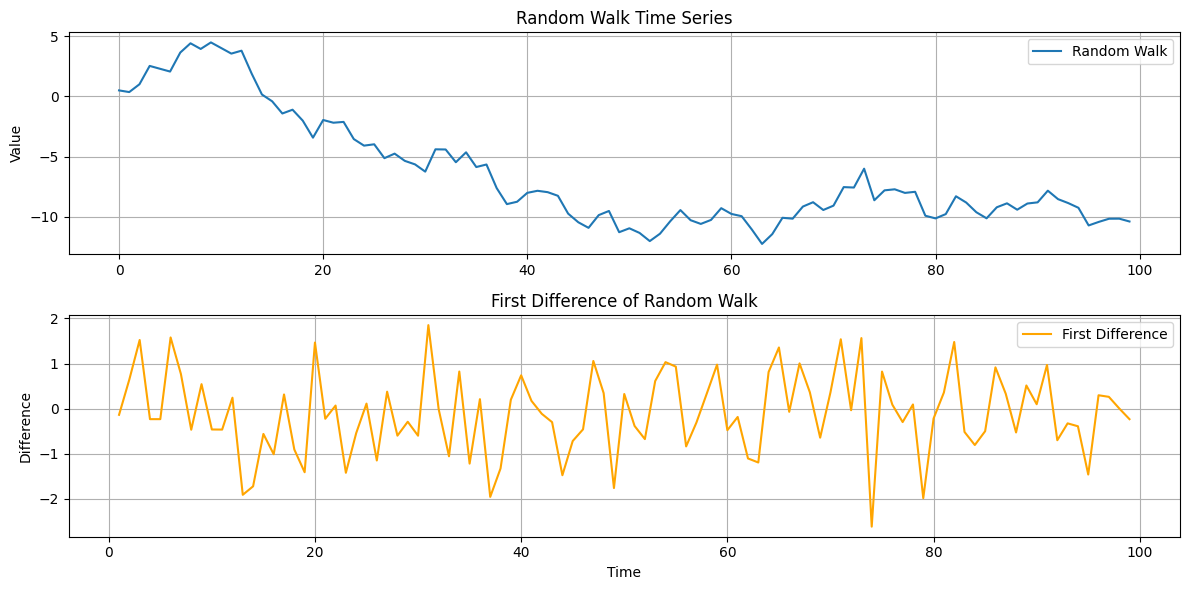

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Simulate a random walk
np.random.seed(42)
n = 100
eps = np.random.normal(0, 1, n)
y = np.cumsum(eps)  # Random walk: y_t = y_{t-1} + eps_t

# Step 2: Create DataFrame and take the first difference
df = pd.DataFrame({'random_walk': y})
df['diff'] = df['random_walk'].diff()

# Step 3: Plot the original random walk and its difference
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(df['random_walk'], label='Random Walk')
plt.title('Random Walk Time Series')
plt.ylabel('Value')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df['diff'], label='First Difference', color='orange')
plt.title('First Difference of Random Walk')
plt.ylabel('Difference')
plt.xlabel('Time')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


#### Basic Time Series Modeling

##### ADF Test and ARIMA

The ARIMA model is denoted as ARIMA(p, d, q), where:

- $p$ is the order of the autoregressive (AR) part
- $d$ is the degree of differencing
- $q$ is the order of the moving average (MA) part

The general ARIMA model is written as:

$$(1 - \sum_{i=1}^{p} \phi_i L^i)(1 - L)^d y_t = (1 + \sum_{i=1}^{q} \theta_i L^i) \varepsilon_t$$

Where:

- $L$ is the lag operator: $L y_t = y_{t-1}$
- $\phi_i$ are the AR parameters
- $\theta_i$ are the MA parameters
- $\varepsilon_t$ is white noise


The Augmented Dickey-Fuller (ADF) test checks for stationarity in a time series.

The test is based on the regression equation:

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{k} \delta_i \Delta y_{t-i} + \varepsilon_t$$

Where:

- $\Delta y_t = y_t - y_{t-1}$ is the first difference
- $t$ is the time trend
- $k$ is the number of lagged differences
- $\varepsilon_t$ is white noise

The null hypothesis is that the series has a unit root (non-stationary), i.e., $\gamma = 0$.  
Rejecting the null implies stationarity.


[*********************100%***********************]  1 of 1 completed


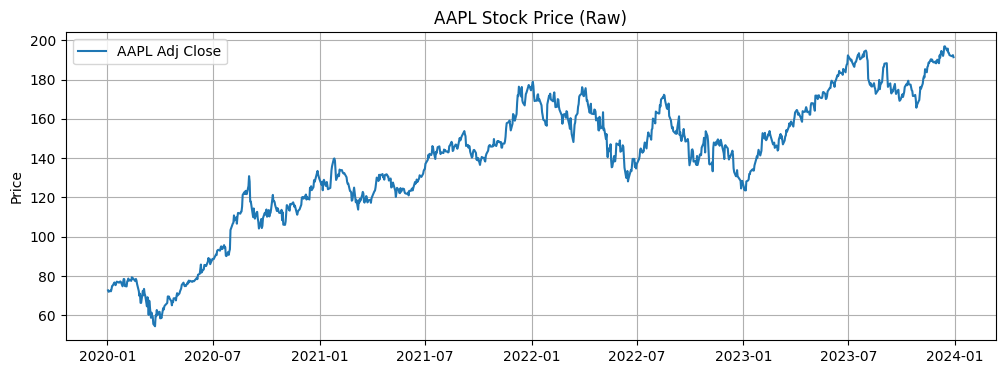

ADF Statistic: -1.5120
p-value: 0.5276


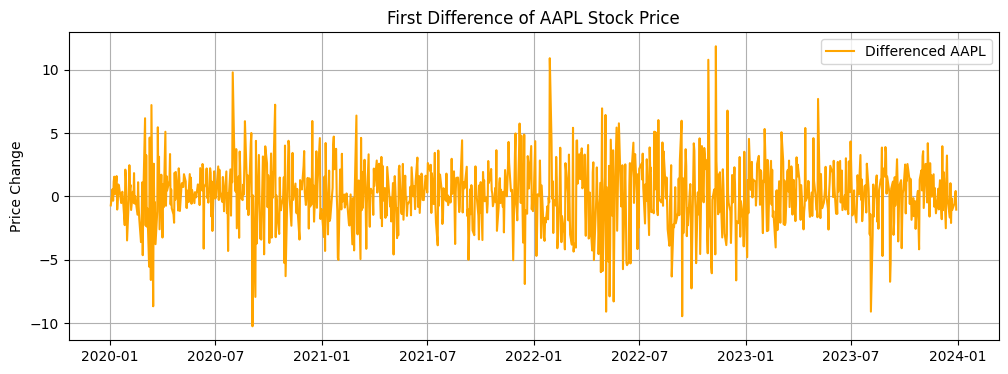

Differenced ADF Statistic: -32.9902
Differenced p-value: 0.0000


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 1006
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2386.006
Date:                Thu, 17 Apr 2025   AIC                           4778.012
Time:                        12:49:11   BIC                           4792.750
Sample:                             0   HQIC                          4783.612
                               - 1006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3903      0.509      0.767      0.443      -0.607       1.388
ma.L1         -0.4323      0.502     -0.861      0.389      -1.416       0.552
sigma2         6.7553      0.228     29.640      0.0

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Step 1: Download AAPL stock data
aapl = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
aapl = aapl['Close']

# Step 2: Plot raw data
plt.figure(figsize=(12, 4))
plt.plot(aapl, label='AAPL Adj Close')
plt.title('AAPL Stock Price (Raw)')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

# Step 3: Check stationarity (ADF test)
result = adfuller(aapl.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
# p-value > 0.05 → non-stationary

# Step 4: Take first difference
aapl_diff = aapl.diff().dropna()

plt.figure(figsize=(12, 4))
plt.plot(aapl_diff, color='orange', label='Differenced AAPL')
plt.title('First Difference of AAPL Stock Price')
plt.ylabel('Price Change')
plt.grid(True)
plt.legend()
plt.show()

# Step 5: Recheck stationarity after differencing
result_diff = adfuller(aapl_diff)
print(f'Differenced ADF Statistic: {result_diff[0]:.4f}')
print(f'Differenced p-value: {result_diff[1]:.4f}')
# p-value < 0.05 → now it's stationary!

# Step 6: Fit ARIMA model (ARIMA(p, d, q)) — we'll use (1,1,1) as a basic example
model = ARIMA(aapl, order=(1,1,1))
fitted_model = model.fit()
print(fitted_model.summary())


#### Feature Engineering Time Series and Simple Machine Learning Model

##### Creating Time Series Features

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Step 1: Download Apple stock data from Yahoo Finance
apple_data = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

# Step 2: Extract date-based features
apple_data['Date'] = apple_data.index  # Use the date as index
apple_data['Year'] = apple_data['Date'].dt.year
apple_data['Month'] = apple_data['Date'].dt.month
apple_data['Day'] = apple_data['Date'].dt.day
apple_data['DayOfWeek'] = apple_data['Date'].dt.weekday  # 0=Monday, 6=Sunday
apple_data['DayOfMonth'] = apple_data['Date'].dt.day
apple_data['WeekOfYear'] = apple_data['Date'].dt.isocalendar().week
apple_data['Quarter'] = apple_data['Date'].dt.quarter
apple_data['IsWeekend'] = apple_data['DayOfWeek'].isin([5, 6]).astype(int)
apple_data['IsMonthStart'] = apple_data['Date'].dt.is_month_start.astype(int)
apple_data['IsMonthEnd'] = apple_data['Date'].dt.is_month_end.astype(int)

# Step 3: Create lag and moving average features
apple_data['Prev_Close'] = apple_data['Close'].shift(1)
apple_data['MA_7'] = apple_data['Close'].rolling(window=7).mean()
apple_data['MA_30'] = apple_data['Close'].rolling(window=30).mean()

# Step 4: Drop rows with NaN values (due to lagging and moving averages)
apple_data = apple_data.dropna()

# Step 5: Define features and target variable
features = ['Year', 'Month', 'DayOfWeek', 'DayOfMonth', 'WeekOfYear', 'Quarter', 'IsWeekend',
            'IsMonthStart', 'IsMonthEnd', 'Prev_Close', 'MA_7', 'MA_30']
X = apple_data[features]
y = apple_data['Close'].shift(-1).dropna()  # Predict the next day's close



[*********************100%***********************]  1 of 1 completed


##### Run Machine Learning Model

stock prices are not i.i.d but correlated, so you don't want to shuffle the data with train_test_split, you must create the split yourself.

In [ ]:
# Align the lengths of X and y by removing the last row of X, which has no corresponding y
X = X.iloc[:-1]  # Drop last row of X
y = y.dropna()   # Drop the NaN value from y

# Step 6: Sequentially split the data (no shuffling)
train_size = int(len(X) * 0.8)  # 80% for training, 20% for testing
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Step 7: Train a regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Predict and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 19.389651473693153
